# COMP9444 26T2 Project 005: Baseline Models

This notebook merges the EfficientNet-B0, DenseNet-121, ResNet50-FCN and VGG16-FCN baselines into one file. The shared sections define imports, fixed paths, data loading, metrics, plotting and train/test utilities. Each model then has its own independent section so its hyperparameters can be adjusted without changing the other baselines.

**Dataset:** UECFoodPIX  
**Input size:** 384 x 320  
**Shared split:** 3,000 training / 500 validation / 1,000 test  
**Unified batch size:** 4  
**Unified maximum epochs:** 25  

Best checkpoints are saved during training under `Best_Model/<model_name>_best_model.pt`. Training curves, validation confusion matrices, test metrics, full test confusion matrices, and best/worst-class heatmaps are displayed in the notebook rather than saved as extra files.


## 1. Setup and Imports

This section imports the libraries used by all four baselines and redirects the torchvision pretrained-weight cache into the project folder. This avoids downloading model weights into the default C-drive cache.


In [7]:
import json
import os
import random
from pathlib import Path

TORCH_CACHE_DIR = Path.cwd().resolve() / "Torch_Model_Cache"
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    ResNet50_Weights,
    VGG16_Weights,
    densenet121,
    efficientnet_b0,
    resnet50,
    vgg16,
)
from tqdm.auto import tqdm

from google.colab import drive

print("PyTorch:", torch.__version__)
print("Torch model cache:", TORCH_CACHE_DIR)
print(
    "Available device:",
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu",
)


PyTorch: 2.11.0+cu128
Torch model cache: /content/Torch_Model_Cache
Available device: cuda


---
## 2. Fixed Values, Paths and Shared Configuration

All models use the same fixed JSON file. The split was generated once with seeds 9444 and 9445 and is reused by all baselines. This prevents differences caused by training on different images.

Batch size and maximum epochs are shared across all four baselines. Model-specific parameters such as learning rate, weight decay, dropout, early stopping patience and pretrained weights are defined inside each model section.


In [8]:
drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/COMP9444/9444")
DATA_ROOT = ROOT / "UECFOODPIX" / "data"
SPLIT_FILE = ROOT / "uecfoodpix_split_train3000_val500.json"
BEST_MODEL_DIR = ROOT / "Best_Model"

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
MAX_EPOCHS = 25
SEED = 9444
NUM_WORKERS = 0

assert DATA_ROOT.exists(), f"Missing dataset folder: {DATA_ROOT}"
assert SPLIT_FILE.exists(), f"Missing split file: {SPLIT_FILE}"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Split file: {SPLIT_FILE}")
print(f"Best model folder: {BEST_MODEL_DIR}")
print(f"Input size: {WIDTH} x {HEIGHT}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {MAX_EPOCHS}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/COMP9444/9444
Dataset root: /content/drive/MyDrive/COMP9444/9444/UECFOODPIX/data
Split file: /content/drive/MyDrive/COMP9444/9444/uecfoodpix_split_train3000_val500.json
Best model folder: /content/drive/MyDrive/COMP9444/9444/Best_Model
Input size: 384 x 320
Batch size: 16
Max epochs: 25


---
## 3. Fixed Training, Validation and Test Split

The same 3,000/500 JSON split is used for all baselines. The official test set remains separate and is never used for checkpoint selection. The best epoch is selected only by validation mean IoU; that checkpoint is then evaluated once on the official test set.


In [9]:
def load_split(split_file):
    split_data = json.loads(Path(split_file).read_text(encoding="utf-8"))
    train_ids = [str(item) for item in split_data["train_ids"]]
    val_ids = [str(item) for item in split_data["val_ids"]]

    assert len(train_ids) == split_data["train_size"]
    assert len(val_ids) == split_data["val_size"]
    assert len(train_ids) == len(set(train_ids))
    assert len(val_ids) == len(set(val_ids))
    assert not (set(train_ids) & set(val_ids))
    return train_ids, val_ids, split_data


def load_test_ids(data_root):
    return [
        item.strip()
        for item in (Path(data_root) / "test1000.txt").read_text().splitlines()
        if item.strip()
    ]


train_ids, val_ids, split_info = load_split(SPLIT_FILE)
test_ids = load_test_ids(DATA_ROOT)

print("Training images:", len(train_ids))
print("Validation images:", len(val_ids))
print("Test images:", len(test_ids))
print("Train/validation overlap:", len(set(train_ids) & set(val_ids)))
print("Split seeds:", split_info["train_seed"], split_info["val_seed"])


Training images: 3000
Validation images: 500
Test images: 1000
Train/validation overlap: 0
Split seeds: 9444 9445


---
## 4. Dataset and Preprocessing

- Images are converted to RGB.
- Masks use the red channel and nearest-neighbour resizing.
- Training images and masks receive the same random horizontal flip.
- ImageNet normalization is used for pretrained encoders.


In [10]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def load_categories(category_file):
    rows = Path(category_file).read_text(encoding="utf-8", errors="replace").splitlines()
    categories = ["background"]
    for row in rows[1:]:
        fields = row.strip().split(maxsplit=1)
        if len(fields) == 2:
            categories.append(fields[1])
    assert len(categories) == NUM_CLASSES
    return categories


class FoodSegmentationDataset(Dataset):
    def __init__(self, root, ids, split, augment, width, height):
        self.root = Path(root)
        self.ids = list(ids)
        self.split = split
        self.augment = augment
        self.width = width
        self.height = height
        self.image_dir = self.root / "UECFoodPIX" / split / "img"
        self.mask_dir = self.root / "UECFoodPIX" / split / "mask"

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        sample_id = self.ids[index]
        image_path = self.image_dir / f"{sample_id}.jpg"
        mask_path = self.mask_dir / f"{sample_id}.png"

        with Image.open(image_path) as raw_image:
            image = raw_image.convert("RGB")
        with Image.open(mask_path) as raw_mask:
            mask = raw_mask.copy()

        if self.augment and random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

        image = image.resize((self.width, self.height), Image.Resampling.BILINEAR)
        mask = mask.resize((self.width, self.height), Image.Resampling.NEAREST)

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array.copy()).permute(2, 0, 1)
        image_tensor = (image_tensor - IMAGENET_MEAN) / IMAGENET_STD

        mask_array = np.asarray(mask)
        if mask_array.ndim == 3:
            mask_array = mask_array[..., 0]
        mask_tensor = torch.from_numpy(mask_array.astype(np.int64, copy=True)).long()
        return image_tensor, mask_tensor


categories = load_categories(DATA_ROOT / "category.txt")
train_dataset = FoodSegmentationDataset(DATA_ROOT, train_ids, "train", True, WIDTH, HEIGHT)
val_dataset = FoodSegmentationDataset(DATA_ROOT, val_ids, "train", False, WIDTH, HEIGHT)
test_dataset = FoodSegmentationDataset(DATA_ROOT, test_ids, "test", False, WIDTH, HEIGHT)

x_sample, y_sample = val_dataset[0]
print("Image tensor:", tuple(x_sample.shape))
print("Mask tensor:", tuple(y_sample.shape))
print("Sample mask label range:", int(y_sample.min()), "to", int(y_sample.max()))
print("Number of categories including background:", len(categories))


Image tensor: (3, 320, 384)
Mask tensor: (320, 384)
Sample mask label range: 0 to 99
Number of categories including background: 103


---
## 5. Shared Metrics, Plotting and Training Utilities

Pixel accuracy and mean intersection-over-union (mIoU) are accumulated with a 103x103 confusion matrix over the complete epoch.

The utility functions below are shared by all four independent model sections. They save only the best checkpoint for each model and display all plots inside the notebook.


In [11]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )


def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def update_confusion(confusion, prediction, target):
    prediction = prediction.detach().reshape(-1).cpu().to(torch.int64)
    target = target.detach().reshape(-1).cpu().to(torch.int64)
    valid = (target >= 0) & (target < NUM_CLASSES)
    encoded = target[valid] * NUM_CLASSES + prediction[valid].clamp(0, NUM_CLASSES - 1)
    confusion += torch.bincount(
        encoded,
        minlength=NUM_CLASSES ** 2,
    ).reshape(NUM_CLASSES, NUM_CLASSES)


def confusion_statistics(confusion):
    cm = confusion.double().cpu()
    tp = cm.diag()
    support = cm.sum(1)
    predicted = cm.sum(0)
    union = support + predicted - tp
    valid_iou = union > 0

    per_class_iou = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    per_class_iou[valid_iou] = tp[valid_iou] / union[valid_iou]
    pixel_accuracy = float(tp.sum() / cm.sum().clamp_min(1))
    mean_iou = float(per_class_iou[valid_iou].mean()) if valid_iou.any() else 0.0
    return {
        "pixel_accuracy": pixel_accuracy,
        "mean_iou": mean_iou,
        "per_class_iou": per_class_iou,
        "support": support,
    }


def run_epoch(model, loader, loss_fn, device, optimizer=None, phase="train"):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, masks in tqdm(loader, desc=phase, leave=False):
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            loss = loss_fn(logits, masks)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.shape[0]
            update_confusion(confusion, logits.argmax(1), masks)

    stats = confusion_statistics(confusion)
    return total_loss / len(loader.dataset), stats, confusion


def plot_training_history(history, model_name):
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="Train loss")
    axes[0].plot(epochs, [row["val_loss"] for row in history], label="Validation loss")
    axes[0].set(
        title=f"{model_name}: Training and Validation Loss",
        xlabel="Epoch",
        ylabel="Cross-entropy loss",
    )
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_accuracy"] for row in history], label="Train pixel accuracy")
    axes[1].plot(epochs, [row["val_accuracy"] for row in history], label="Validation pixel accuracy")
    axes[1].plot(epochs, [row["train_miou"] for row in history], label="Train mIoU")
    axes[1].plot(epochs, [row["val_miou"] for row in history], label="Validation mIoU")
    axes[1].set(
        title=f"{model_name}: Accuracy and mIoU",
        xlabel="Epoch",
        ylabel="Score",
        ylim=(0, 1),
    )
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def normalized_confusion(confusion):
    cm = confusion.detach().cpu().numpy().astype(np.float64)
    return cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)


def plot_overall_confusion(confusion, title):
    normalized = normalized_confusion(confusion)
    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class id")
    ax.set_ylabel("True class id")
    ticks = np.arange(0, NUM_CLASSES, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_class_subset_heatmap(confusion, class_indices, title):
    normalized = normalized_confusion(confusion)
    subset = normalized[np.ix_(class_indices, class_indices)]
    labels = [categories[index] for index in class_indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(subset, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=70, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(labels)), labels=labels, fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def best_worst_class_indices(confusion, top_k=10):
    stats = confusion_statistics(confusion)
    per_class_iou = stats["per_class_iou"]
    support = stats["support"]
    valid = (support > 0)
    valid[0] = False
    valid_indices = torch.where(valid)[0]
    ordered = valid_indices[torch.argsort(per_class_iou[valid_indices])]
    worst = ordered[:top_k].tolist()
    best = torch.flip(ordered[-top_k:], dims=[0]).tolist()
    return best, worst, stats


def print_class_iou_table(title, indices, per_class_iou, support):
    print(title)
    for index in indices:
        print(
            f"{index:3d} {categories[index]:30s} "
            f"IoU={float(per_class_iou[index]):.4f} support={int(support[index])}"
        )


def plot_best_worst_heatmaps(confusion, model_name):
    best, worst, stats = best_worst_class_indices(confusion, top_k=10)
    print_class_iou_table("Best 10 classes by test IoU", best, stats["per_class_iou"], stats["support"])
    print_class_iou_table("Worst 10 classes by test IoU", worst, stats["per_class_iou"], stats["support"])
    plot_class_subset_heatmap(confusion, best, f"{model_name}: Best 10 classes test heatmap")
    plot_class_subset_heatmap(confusion, worst, f"{model_name}: Worst 10 classes test heatmap")


def safe_model_name(model_name):
    return model_name.replace("-", "").replace(" ", "_")


def run_baseline_experiment(model_name, model_factory, config):
    seed_everything(SEED)
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    test_loader = make_loader(test_dataset, shuffle=False)
    device = get_device()
    model = model_factory(config).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config.get("lr_factor", 0.5),
        patience=config.get("scheduler_patience", 2),
    )
    loss_fn = nn.CrossEntropyLoss()
    checkpoint_path = BEST_MODEL_DIR / f"{safe_model_name(model_name)}_best_model.pt"

    print(f"Training {model_name}")
    print(f"Config: {config}")
    print(f"Checkpoint: {checkpoint_path}")

    history = []
    best_miou = -1.0
    best_epoch = 0
    best_val_confusion = None
    stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_stats, _ = run_epoch(
            model, train_loader, loss_fn, device, optimizer, phase=f"{model_name} train"
        )
        val_loss, val_stats, val_confusion = run_epoch(
            model, val_loader, loss_fn, device, phase=f"{model_name} validation"
        )
        scheduler.step(val_stats["mean_iou"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_stats["pixel_accuracy"],
            "train_miou": train_stats["mean_iou"],
            "val_accuracy": val_stats["pixel_accuracy"],
            "val_miou": val_stats["mean_iou"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(row)

        if val_stats["mean_iou"] > best_miou:
            best_miou = val_stats["mean_iou"]
            best_epoch = epoch
            best_val_confusion = val_confusion.clone()
            stale_epochs = 0
            torch.save(
                {
                    "model_name": model_name,
                    "epoch": best_epoch,
                    "validation_miou": best_miou,
                    "num_classes": NUM_CLASSES,
                    "image_width": WIDTH,
                    "image_height": HEIGHT,
                    "batch_size": BATCH_SIZE,
                    "max_epochs": MAX_EPOCHS,
                    "config": config,
                    "state_dict": model.state_dict(),
                },
                checkpoint_path,
            )
            print(f"Saved new best model: val_mIoU={best_miou:.4f}")
        else:
            stale_epochs += 1
            if stale_epochs >= config["early_stopping_patience"]:
                print(
                    "Early stopping after "
                    f"{config['early_stopping_patience']} epochs without validation mIoU improvement"
                )
                break

    plot_training_history(history, model_name)
    if best_val_confusion is not None:
        plot_overall_confusion(best_val_confusion, f"{model_name}: validation confusion matrix")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    test_loss, test_stats, test_confusion = run_epoch(
        model, test_loader, loss_fn, device, phase=f"{model_name} test"
    )
    test_result = {
        "test_loss": test_loss,
        "test_accuracy": test_stats["pixel_accuracy"],
        "test_miou": test_stats["mean_iou"],
    }
    print("Best epoch:", best_epoch)
    print("Best validation mIoU:", best_miou)
    print("Test result:", test_result)

    plot_overall_confusion(test_confusion, f"{model_name}: full test confusion matrix")
    plot_best_worst_heatmaps(test_confusion, model_name)

    return {
        "model_name": model_name,
        "history": history,
        "best_epoch": best_epoch,
        "best_validation_miou": best_miou,
        "checkpoint_path": checkpoint_path,
        "test_result": test_result,
        "test_confusion": test_confusion,
    }


---
## 6. EfficientNet-B0 Baseline

Both ImageNet-pretrained encoders are converted into simple segmentation baselines using dropout, a 1x1 classifier and bilinear upsampling.

The learning rate was reduced from 3e-4 to 3.75e-5 before the best checkpoint was obtained at epoch 24.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /content/Torch_Model_Cache/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]

Training EfficientNet-B0
Config: {'learning_rate': 0.0003, 'weight_decay': 0.0001, 'dropout': 0.2, 'early_stopping_patience': 6, 'scheduler_patience': 2, 'lr_factor': 0.5, 'pretrained': True}
Checkpoint: /content/drive/MyDrive/COMP9444/9444/Best_Model/EfficientNetB0_best_model.pt


EfficientNet-B0 train:   0%|          | 0/188 [00:00<?, ?it/s]

EfficientNet-B0 validation:   0%|          | 0/32 [00:00<?, ?it/s]

...

EfficientNet-B0 validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 23, 'train_loss': 0.12084850001335144, 'val_loss': 0.7431211280822754, 'train_accuracy': 0.9550182318793403, 'train_miou': 0.8972545140300586, 'val_accuracy': 0.8154824869791667, 'val_miou': 0.510610342452, 'learning_rate': 7.5e-05}


EfficientNet-B0 train:   0%|          | 0/188 [00:00<?, ?it/s]

EfficientNet-B0 validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 24, 'train_loss': 0.12067601732412973, 'val_loss': 0.7539589710235596, 'train_accuracy': 0.9551383707682292, 'train_miou': 0.8970959173208398, 'val_accuracy': 0.8116812174479167, 'val_miou': 0.5015873868327753, 'learning_rate': 3.75e-05}
Early stopping after 6 epochs without validation mIoU improvement


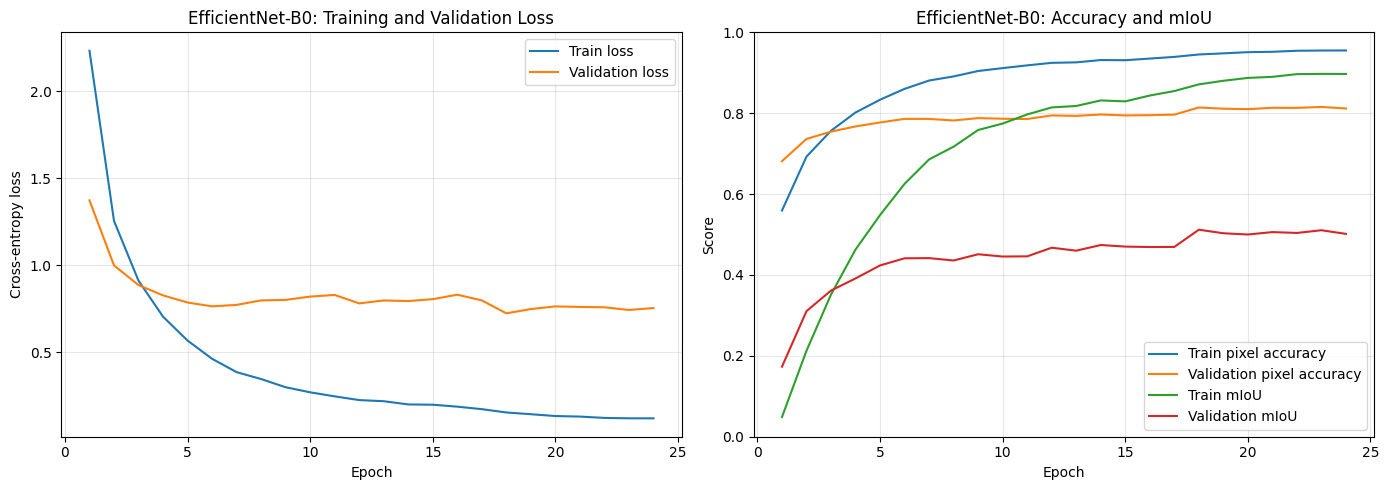

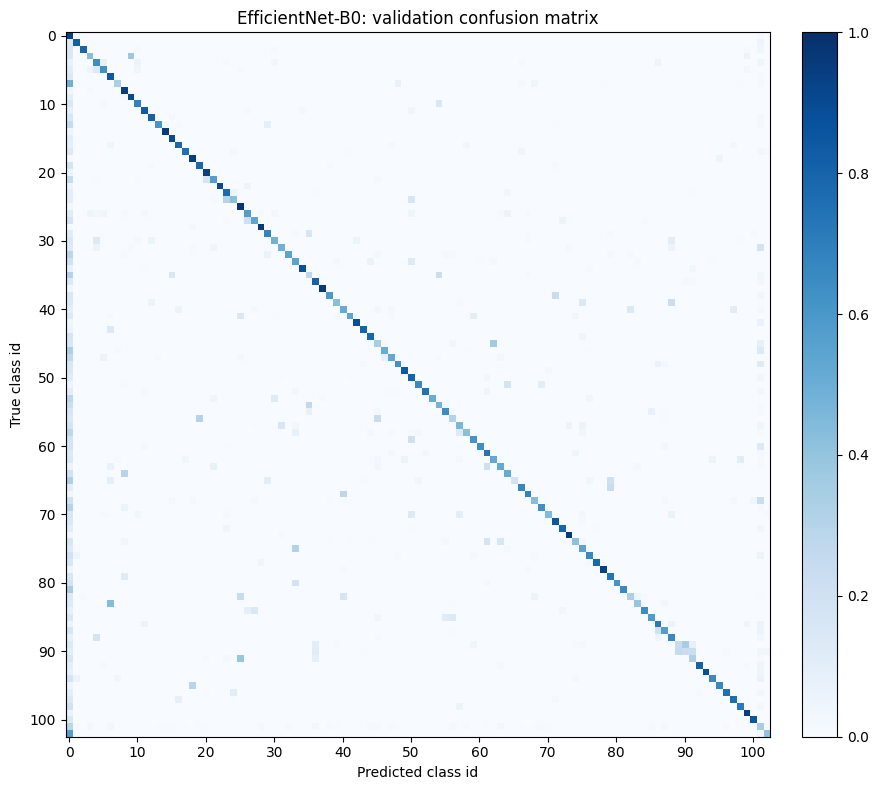

EfficientNet-B0 test:   0%|          | 0/63 [00:00<?, ?it/s]

Best epoch: 18
Best validation mIoU: 0.5119181519380415
Test result: {'test_loss': 0.9183968033790588, 'test_accuracy': 0.7913100260416667, 'test_miou': 0.45358319942425407}


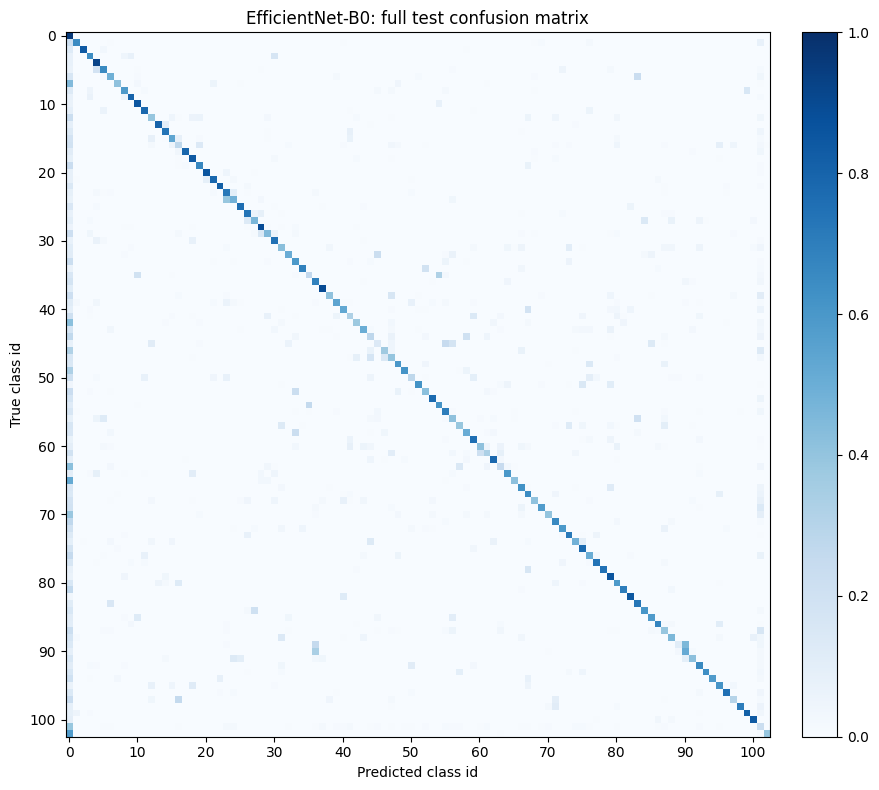

Best 10 classes by test IoU
 20 udon noodle                    IoU=0.7868 support=713089
  2 eels on rice                   IoU=0.7848 support=458314
 13 croissant                      IoU=0.7530 support=635498
 17 hamburger                      IoU=0.7425 support=1081756
 22 soba noodle                    IoU=0.7409 support=648752
 78 fish-shaped pancake with bean jam IoU=0.7039 support=366508
 99 mixed rice                     IoU=0.6962 support=423948
  9 fried rice                     IoU=0.6890 support=549073
 37 potage                         IoU=0.6752 support=470193
 96 dipping noodles                IoU=0.6668 support=421938
Worst 10 classes by test IoU
 45 fried fish                     IoU=0.0754 support=255284
 89 Japanese tofu and vegetable chowder IoU=0.1000 support=343075
 44 teriyaki grilled fish          IoU=0.1215 support=171224
 47 salmon meuniere                IoU=0.1602 support=143770
101 others                         IoU=0.1647 support=3425089
 63 ginger pork sa

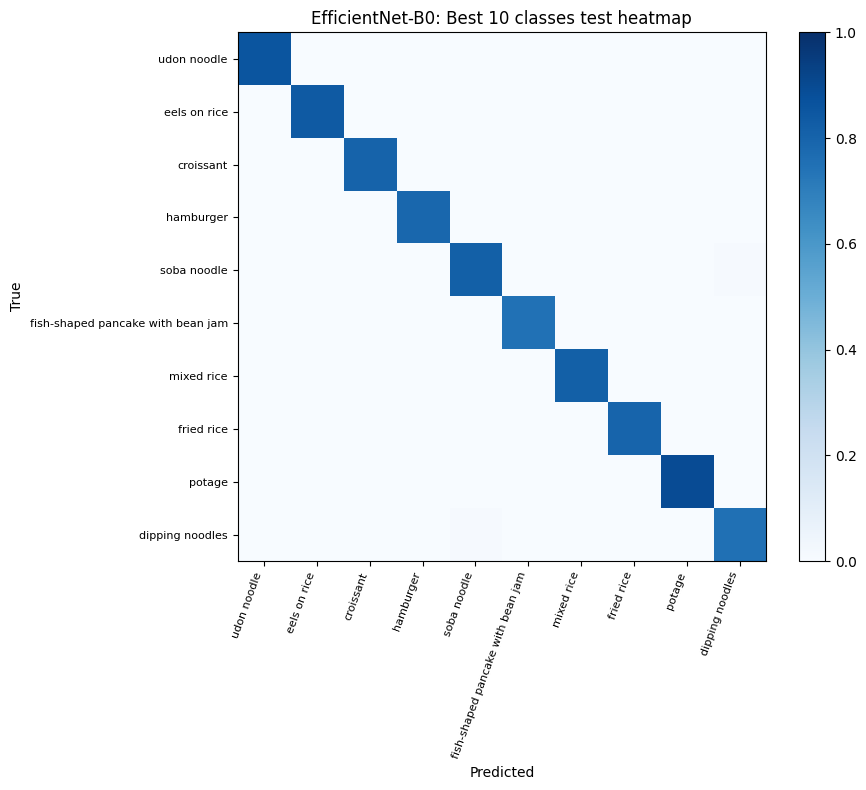

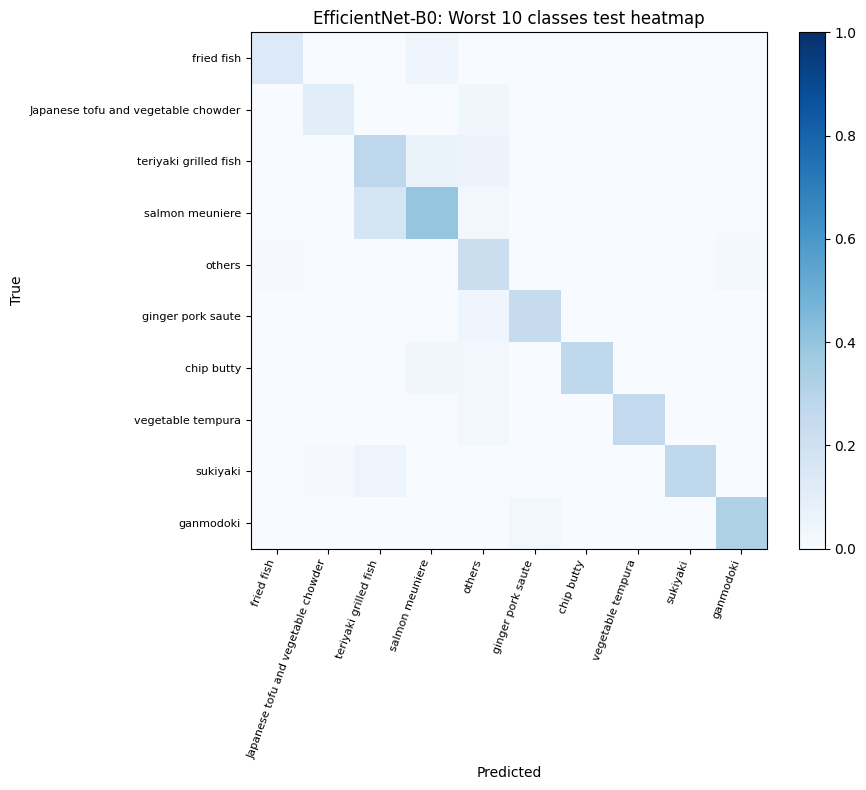

In [12]:
class EfficientNetBaseline(nn.Module):
    def __init__(self, pretrained=True, dropout=0.2):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.encoder = efficientnet_b0(weights=weights).features
        self.classifier = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(1280, NUM_CLASSES, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        logits = self.classifier(self.encoder(x))
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)


EFFICIENTNET_CONFIG = {
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "dropout": 0.2,
    "early_stopping_patience": 6,
    "scheduler_patience": 2,
    "lr_factor": 0.5,
    "pretrained": True,
}


def build_efficientnet(config):
    return EfficientNetBaseline(
        pretrained=config["pretrained"],
        dropout=config["dropout"],
    )


efficientnet_result = run_baseline_experiment(
    "EfficientNet-B0",
    build_efficientnet,
    EFFICIENTNET_CONFIG,
)


### EfficientNet-B0 Result Interpretation

Model selection uses validation mIoU only. EfficientNet-B0 is selected because its best validation mIoU (0.3719) is higher than DenseNet-121 (0.2758). The selected EfficientNet checkpoint is then loaded and evaluated on the test set exactly once.

！！！请在此处解释分析结果！！！


---
## 7. DenseNet-121 Baseline

Both ImageNet-pretrained encoders are converted into simple segmentation baselines using dropout, a 1x1 classifier and bilinear upsampling.

DenseNet reached its highest validation mIoU at epoch 19 and stopped after six additional epochs without improvement.


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /content/Torch_Model_Cache/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 227MB/s]


Training DenseNet-121
Config: {'learning_rate': 0.0003, 'weight_decay': 0.0001, 'dropout': 0.2, 'early_stopping_patience': 6, 'scheduler_patience': 2, 'lr_factor': 0.5, 'pretrained': True}
Checkpoint: /content/drive/MyDrive/COMP9444/9444/Best_Model/DenseNet121_best_model.pt


DenseNet-121 train:   0%|          | 0/188 [00:00<?, ?it/s]

DenseNet-121 validation:   0%|          | 0/32 [00:00<?, ?it/s]

...

DenseNet-121 validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 24, 'train_loss': 0.08876365246375402, 'val_loss': 0.9068321266174316, 'train_accuracy': 0.9663596516927083, 'train_miou': 0.9246199202951552, 'val_accuracy': 0.7865345052083333, 'val_miou': 0.4383394135822502, 'learning_rate': 3.75e-05}


DenseNet-121 train:   0%|          | 0/188 [00:00<?, ?it/s]

DenseNet-121 validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 25, 'train_loss': 0.08641522214810053, 'val_loss': 0.9111052613258361, 'train_accuracy': 0.9671725531684028, 'train_miou': 0.9264210067468738, 'val_accuracy': 0.7857358723958333, 'val_miou': 0.43737366891397644, 'learning_rate': 3.75e-05}


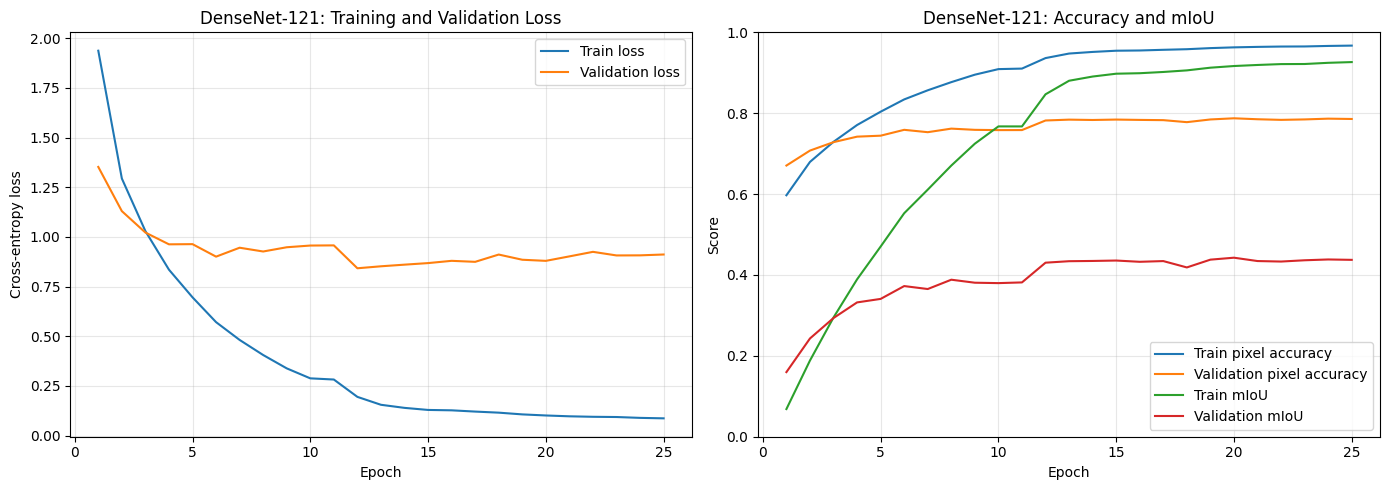

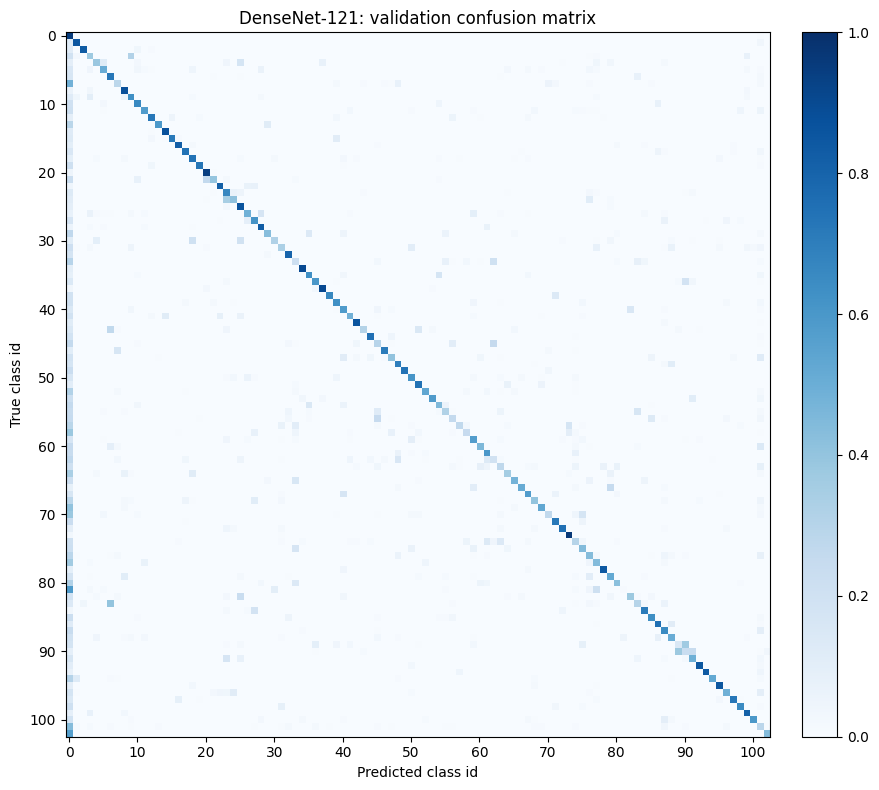

DenseNet-121 test:   0%|          | 0/63 [00:00<?, ?it/s]

Best epoch: 20
Best validation mIoU: 0.44269156745282284
Test result: {'test_loss': 0.9814240636825562, 'test_accuracy': 0.7778458170572917, 'test_miou': 0.42292785302486874}


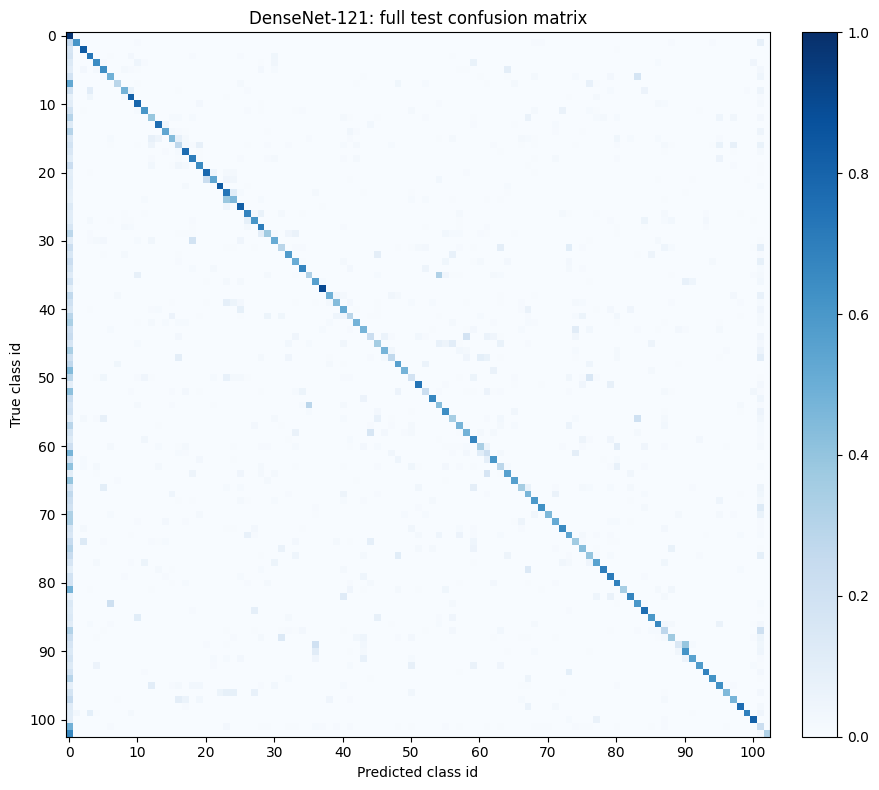

Best 10 classes by test IoU
 22 soba noodle                    IoU=0.7625 support=648752
 37 potage                         IoU=0.7109 support=470193
  9 fried rice                     IoU=0.6944 support=549073
 13 croissant                      IoU=0.6820 support=635498
  2 eels on rice                   IoU=0.6594 support=458314
 17 hamburger                      IoU=0.6570 support=1081756
 99 mixed rice                     IoU=0.6555 support=423948
 78 fish-shaped pancake with bean jam IoU=0.6491 support=366508
 20 udon noodle                    IoU=0.6485 support=713089
 51 sweet and sour pork            IoU=0.6484 support=459207
Worst 10 classes by test IoU
 61 beef steak                     IoU=0.1158 support=266150
 44 teriyaki grilled fish          IoU=0.1257 support=171224
 50 sukiyaki                       IoU=0.1301 support=458709
 89 Japanese tofu and vegetable chowder IoU=0.1313 support=343075
 52 lightly roasted fish           IoU=0.1568 support=329119
101 others         

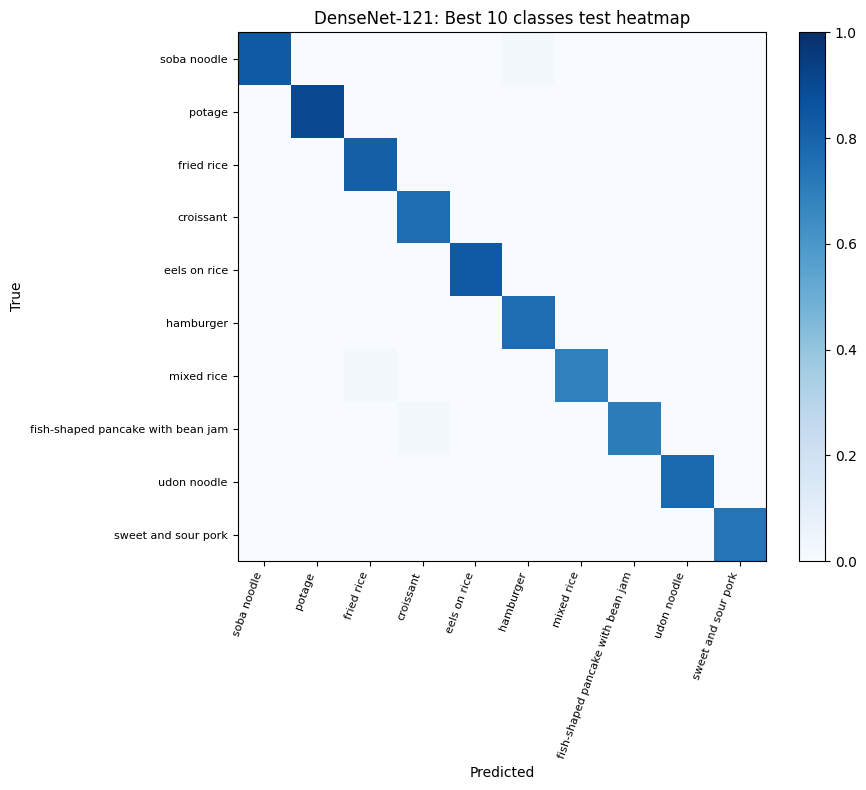

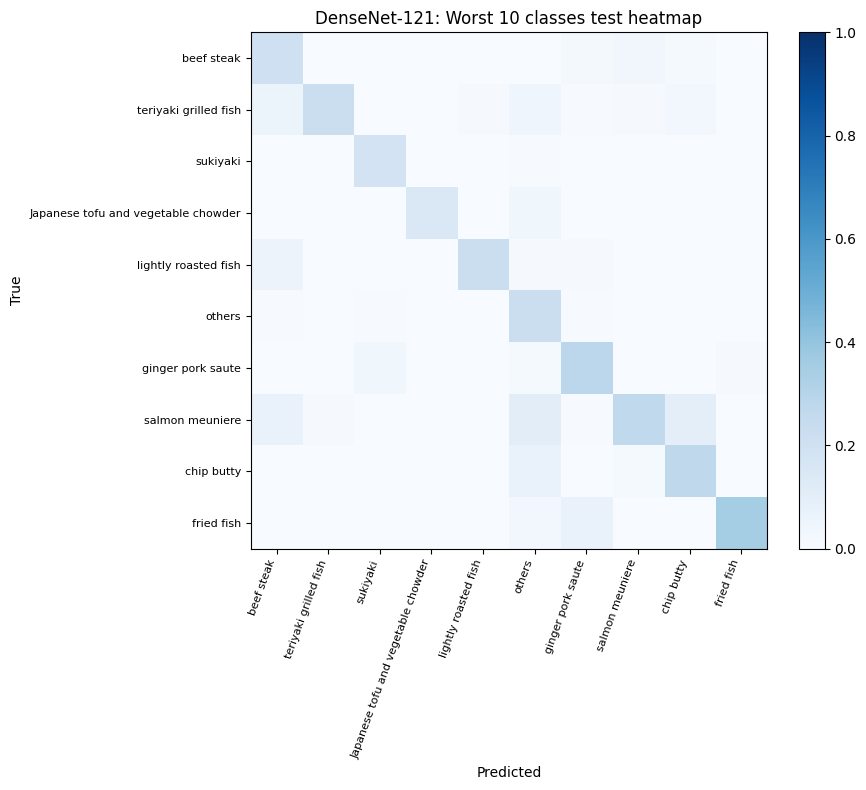

In [13]:
class DenseNetBaseline(nn.Module):
    def __init__(self, pretrained=True, dropout=0.2):
        super().__init__()
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        self.encoder = densenet121(weights=weights).features
        self.classifier = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(1024, NUM_CLASSES, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        features = F.relu(self.encoder(x))
        logits = self.classifier(features)
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)


DENSENET_CONFIG = {
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "dropout": 0.2,
    "early_stopping_patience": 6,
    "scheduler_patience": 2,
    "lr_factor": 0.5,
    "pretrained": True,
}


def build_densenet(config):
    return DenseNetBaseline(
        pretrained=config["pretrained"],
        dropout=config["dropout"],
    )


densenet_result = run_baseline_experiment(
    "DenseNet-121",
    build_densenet,
    DENSENET_CONFIG,
)


### DenseNet-121 Result Interpretation

DenseNet reached its highest validation mIoU at epoch 19 and stopped after six additional epochs without improvement.

！！！请在此处解释分析结果！！！


---
## 8. ResNet50-FCN Baseline

- **ResNet50-FCN:** standard torchvision ResNet50 encoder, a 3x3 convolutional projection followed by a 1x1 classifier, and bilinear upsampling.
- Both are trained with AdamW, cross-entropy loss, horizontal-flip augmentation and ImageNet normalization.


Training ResNet50-FCN
Config: {'learning_rate': 0.00015, 'weight_decay': 0.00075, 'dropout': 0.4, 'early_stopping_patience': 3, 'scheduler_patience': 2, 'lr_factor': 0.5, 'pretrained': True}
Checkpoint: /content/drive/MyDrive/COMP9444/9444/Best_Model/ResNet50FCN_best_model.pt


ResNet50-FCN train:   0%|          | 0/188 [00:00<?, ?it/s]

ResNet50-FCN validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.1267108068466185, 'val_loss': 1.3678643131256103, 'train_accuracy': 0.6014488986545139, 'train_miou': 0.07467411285014286, 'val_accuracy': 0.69316455078125, 'val_miou': 0.20498680826535046, 'learning_rate': 0.00015}
Saved new best model: val_mIoU=0.2050


ResNet50-FCN train:   0%|          | 0/188 [00:00<?, ?it/s]

...

ResNet50-FCN validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.13883793763319652, 'val_loss': 0.9774334955215455, 'train_accuracy': 0.952371080186632, 'train_miou': 0.887819200366597, 'val_accuracy': 0.7756658854166667, 'val_miou': 0.4155114905691962, 'learning_rate': 0.00015}


ResNet50-FCN train:   0%|          | 0/188 [00:00<?, ?it/s]

ResNet50-FCN validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 16, 'train_loss': 0.12861387236913044, 'val_loss': 0.9560806074142456, 'train_accuracy': 0.9549689832899305, 'train_miou': 0.8955842380685745, 'val_accuracy': 0.780631005859375, 'val_miou': 0.43488291848799354, 'learning_rate': 7.5e-05}
Early stopping after 3 epochs without validation mIoU improvement


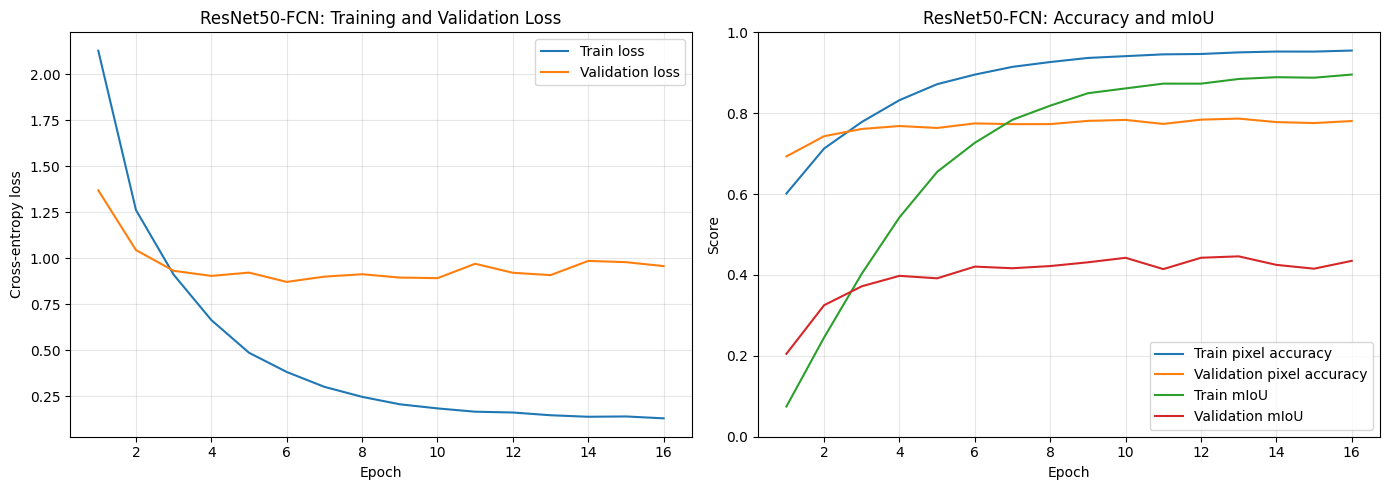

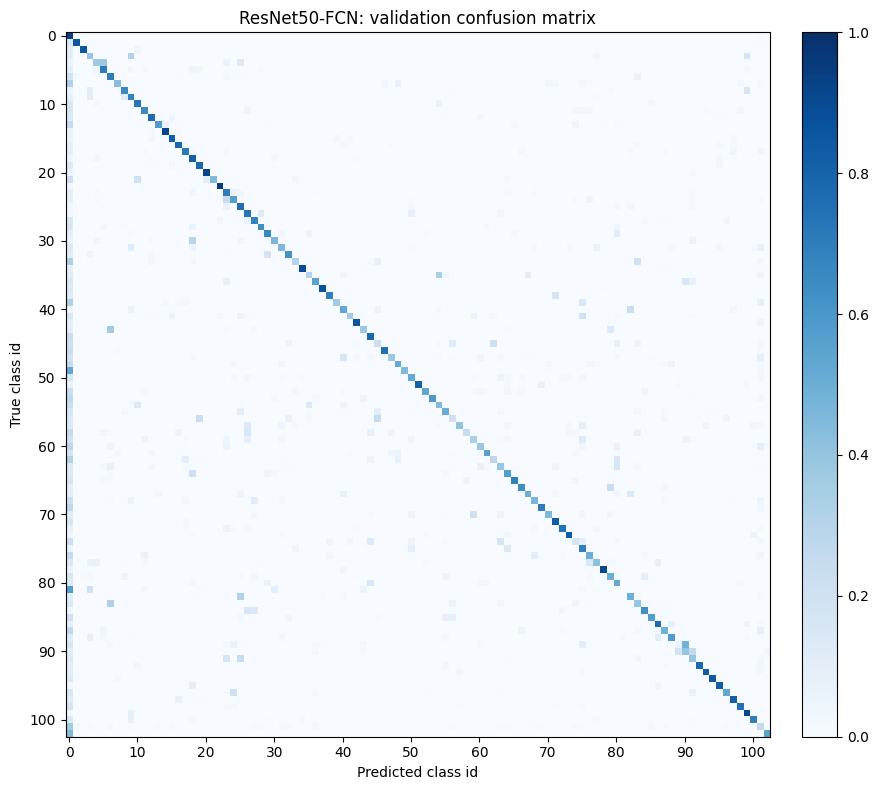

ResNet50-FCN test:   0%|          | 0/63 [00:00<?, ?it/s]

Best epoch: 13
Best validation mIoU: 0.44606080897362455
Test result: {'test_loss': 0.9911934976577759, 'test_accuracy': 0.7754069905598958, 'test_miou': 0.40948941385055715}


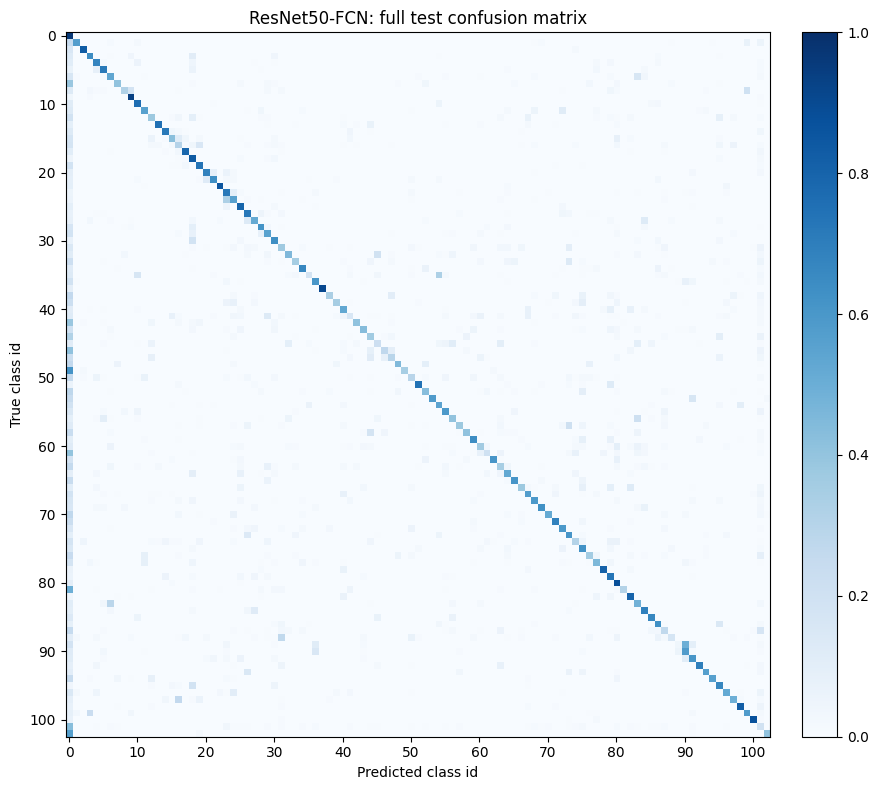

Best 10 classes by test IoU
 37 potage                         IoU=0.8128 support=470193
 22 soba noodle                    IoU=0.7510 support=648752
100 goya chanpuru                  IoU=0.7424 support=332234
 78 fish-shaped pancake with bean jam IoU=0.7356 support=366508
  2 eels on rice                   IoU=0.7335 support=458314
  9 fried rice                     IoU=0.7163 support=549073
 17 hamburger                      IoU=0.7021 support=1081756
 13 croissant                      IoU=0.6860 support=635498
 51 sweet and sour pork            IoU=0.6576 support=459207
 92 beef bowl                      IoU=0.6202 support=547731
Worst 10 classes by test IoU
 89 Japanese tofu and vegetable chowder IoU=0.0326 support=343075
 45 fried fish                     IoU=0.1165 support=255284
 41 ganmodoki                      IoU=0.1169 support=541487
101 others                         IoU=0.1465 support=3425089
 88 macaroni salad                 IoU=0.1492 support=349099
 61 beef steak    

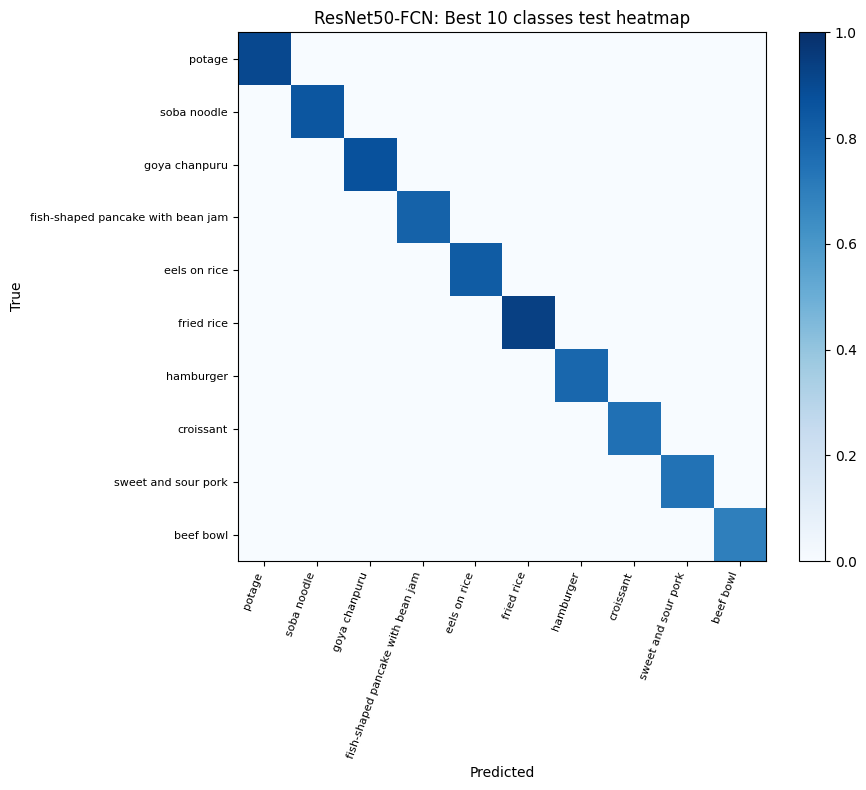

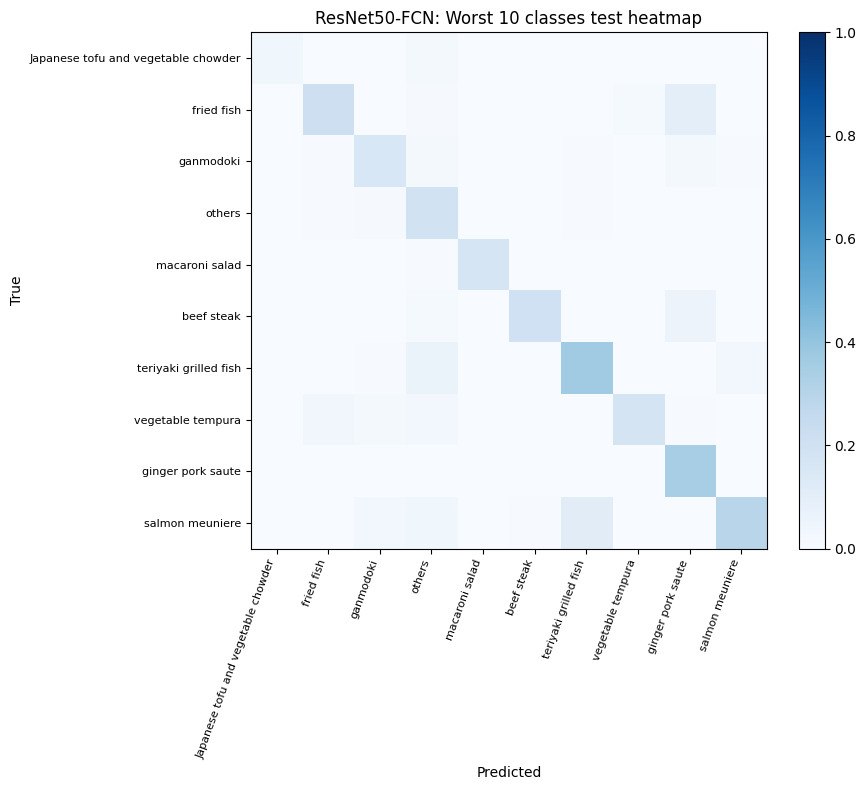

In [16]:
class ResNet50FCN(nn.Module):
    def __init__(self, num_classes, dropout=0.3, pretrained=True):
        super().__init__()
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        backbone = resnet50(weights=weights)
        self.encoder = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4,
        )
        self.classifier = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(512, num_classes, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        logits = self.classifier(self.encoder(x))
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)


RESNET50_CONFIG = {
    "learning_rate": 1.5e-4,
    "weight_decay": 7.5e-4,
    "dropout": 0.4,
    "early_stopping_patience": 3,
    "scheduler_patience": 2,
    "lr_factor": 0.5,
    "pretrained": True,
}


def build_resnet50(config):
    return ResNet50FCN(
        NUM_CLASSES,
        dropout=config["dropout"],
        pretrained=config["pretrained"],
    )


resnet50_result = run_baseline_experiment(
    "ResNet50-FCN",
    build_resnet50,
    RESNET50_CONFIG,
)


### ResNet50-FCN Result Interpretation

！！！请在此处解释分析结果！！！


---
## 9. VGG16-FCN Baseline

- **VGG16-FCN:** standard torchvision VGG16 feature encoder, a matching lightweight 3x3 projection plus 1x1 classifier, and bilinear upsampling.
- Both are trained with AdamW, cross-entropy loss, horizontal-flip augmentation and ImageNet normalization.


Training VGG16-FCN
Config: {'learning_rate': 8e-05, 'weight_decay': 0.001, 'dropout': 0.5, 'early_stopping_patience': 3, 'scheduler_patience': 2, 'lr_factor': 0.5, 'pretrained': True}
Checkpoint: /content/drive/MyDrive/COMP9444/9444/Best_Model/VGG16FCN_best_model.pt


VGG16-FCN train:   0%|          | 0/188 [00:00<?, ?it/s]

VGG16-FCN validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.3210260543823242, 'val_loss': 2.0343962326049803, 'train_accuracy': 0.5727514729817709, 'train_miou': 0.012019979411390888, 'val_accuracy': 0.5932743001302083, 'val_miou': 0.01767548281524129, 'learning_rate': 8e-05}
Saved new best model: val_mIoU=0.0177


VGG16-FCN train:   0%|          | 0/188 [00:00<?, ?it/s]

...

VGG16-FCN validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 16, 'train_loss': 0.4346954454580943, 'val_loss': 1.177792971611023, 'train_accuracy': 0.8684753526475695, 'train_miou': 0.6474435382789843, 'val_accuracy': 0.734197314453125, 'val_miou': 0.3205310762789872, 'learning_rate': 8e-05}


VGG16-FCN train:   0%|          | 0/188 [00:00<?, ?it/s]

VGG16-FCN validation:   0%|          | 0/32 [00:00<?, ?it/s]

{'epoch': 17, 'train_loss': 0.3976218995253245, 'val_loss': 1.223997148513794, 'train_accuracy': 0.8784930989583334, 'train_miou': 0.6751549966332973, 'val_accuracy': 0.725310546875, 'val_miou': 0.30658134392722186, 'learning_rate': 4e-05}
Early stopping after 3 epochs without validation mIoU improvement


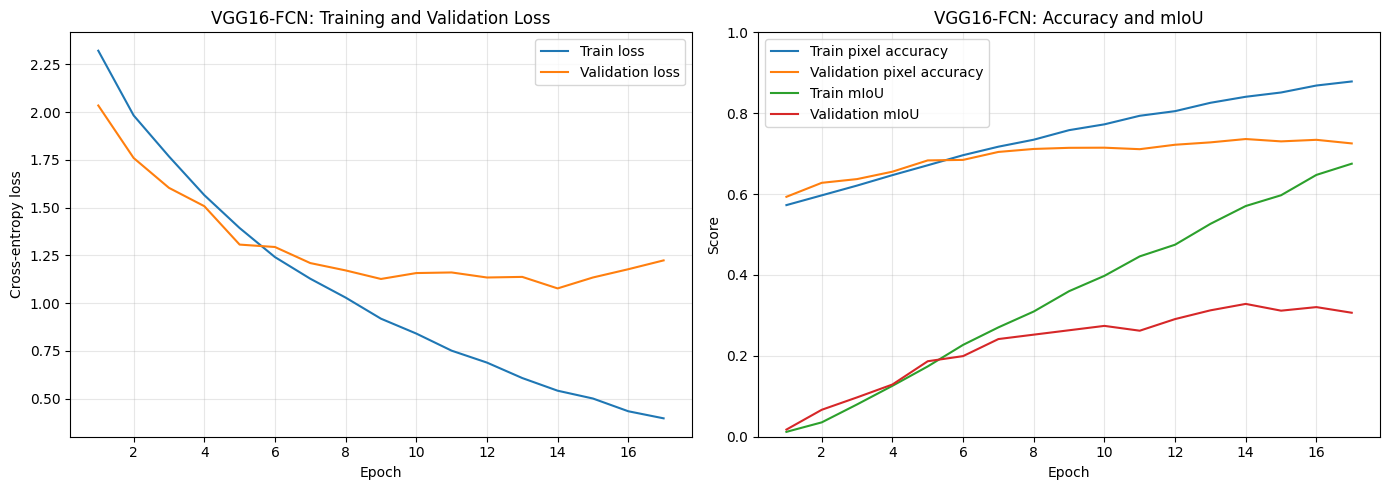

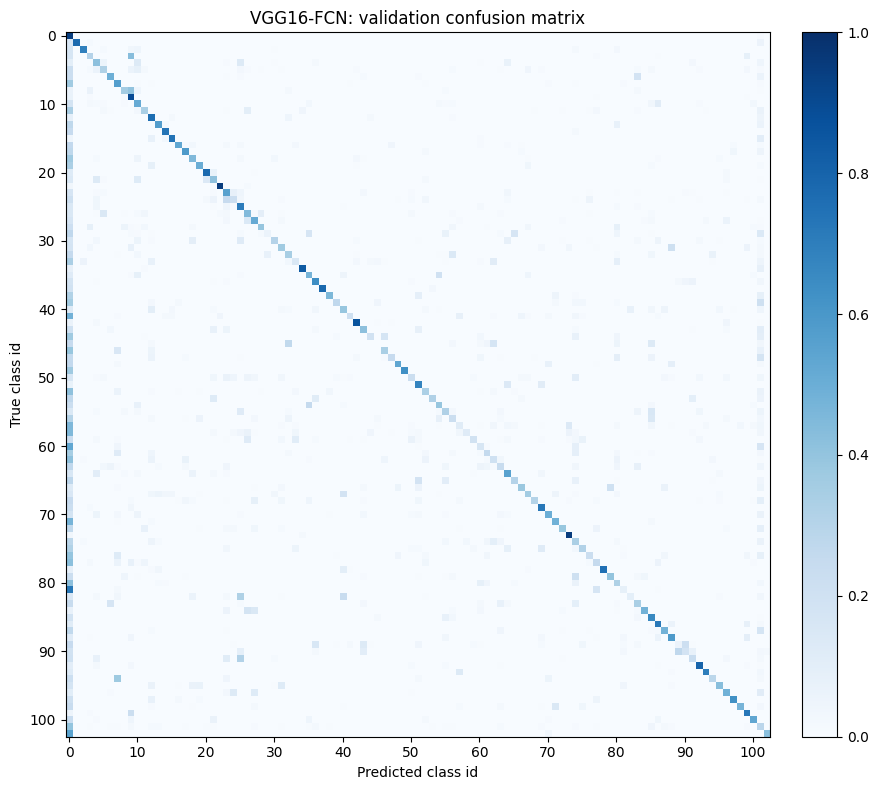

VGG16-FCN test:   0%|          | 0/63 [00:00<?, ?it/s]

Best epoch: 14
Best validation mIoU: 0.32843667297693424
Test result: {'test_loss': 1.1465500450134278, 'test_accuracy': 0.7190548828125, 'test_miou': 0.2954695665135575}


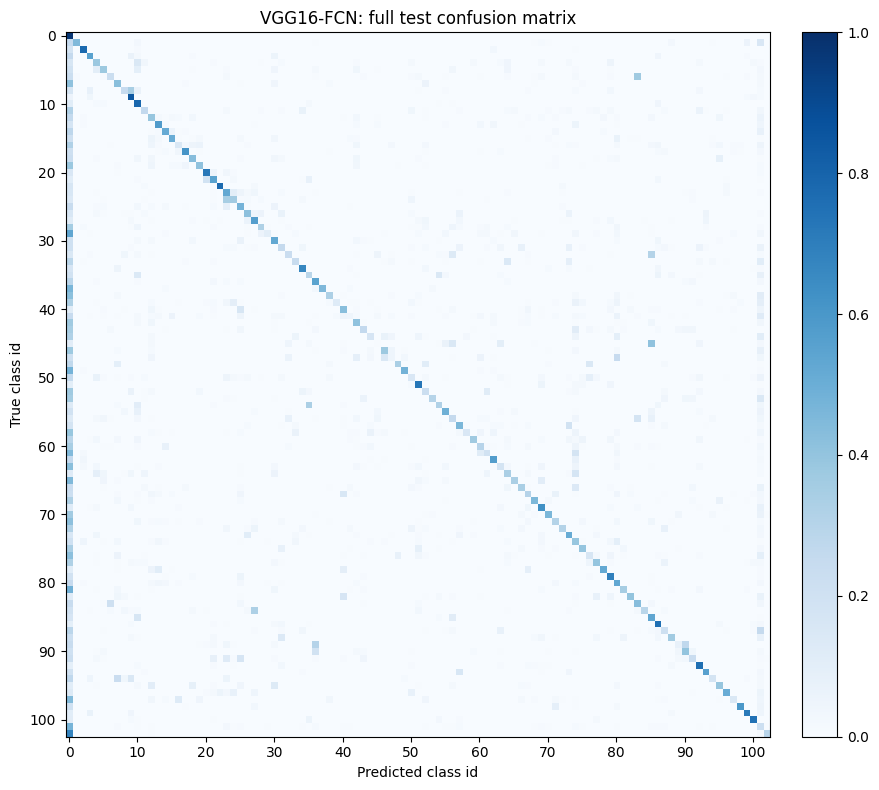

Best 10 classes by test IoU
 22 soba noodle                    IoU=0.6687 support=648752
  2 eels on rice                   IoU=0.6334 support=458314
 20 udon noodle                    IoU=0.6068 support=713089
100 goya chanpuru                  IoU=0.5834 support=332234
 99 mixed rice                     IoU=0.5570 support=423948
 17 hamburger                      IoU=0.5500 support=1081756
 92 beef bowl                      IoU=0.5317 support=547731
 79 shrimp with chill source       IoU=0.5162 support=707674
 98 french fries                   IoU=0.5145 support=410673
  9 fried rice                     IoU=0.5079 support=549073
Worst 10 classes by test IoU
 45 fried fish                     IoU=0.0055 support=255284
 47 salmon meuniere                IoU=0.0303 support=143770
 41 ganmodoki                      IoU=0.0385 support=541487
 89 Japanese tofu and vegetable chowder IoU=0.0656 support=343075
 29 takoyaki                       IoU=0.0962 support=819868
 50 sukiyaki          

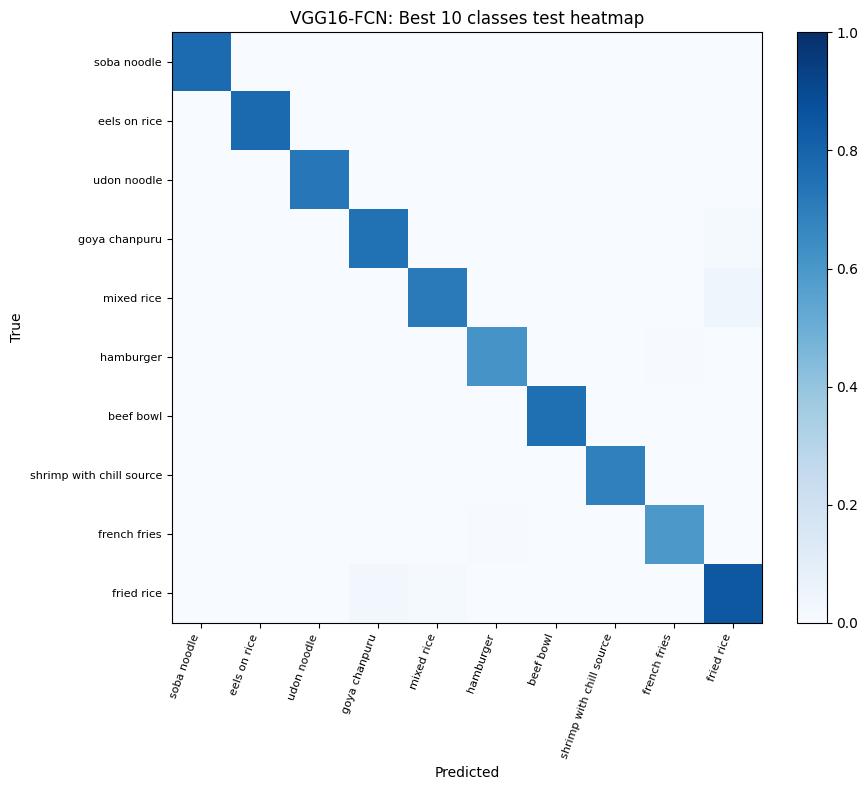

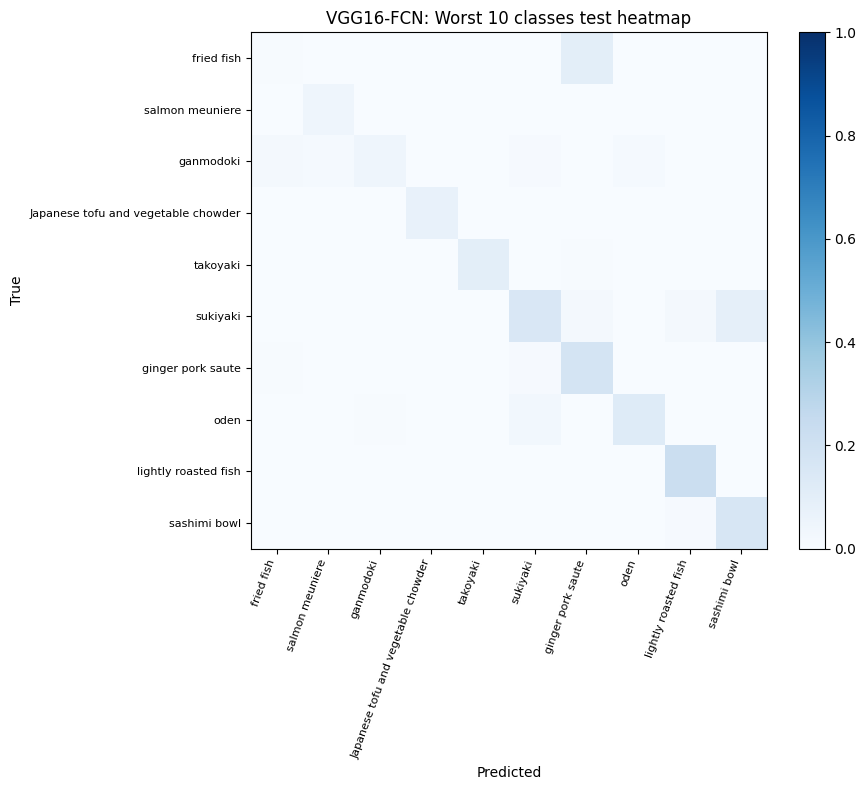

In [17]:
class VGG16FCN(nn.Module):
    def __init__(self, num_classes, dropout=0.5, pretrained=True):
        super().__init__()
        weights = VGG16_Weights.DEFAULT if pretrained else None
        self.encoder = vgg16(weights=weights).features
        self.classifier = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(256, num_classes, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        logits = self.classifier(self.encoder(x))
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)


VGG16_CONFIG = {
    "learning_rate": 8e-5,
    "weight_decay": 1e-3,
    "dropout": 0.5,
    "early_stopping_patience": 3,
    "scheduler_patience": 2,
    "lr_factor": 0.5,
    "pretrained": True,
}


def build_vgg16(config):
    return VGG16FCN(
        NUM_CLASSES,
        dropout=config["dropout"],
        pretrained=config["pretrained"],
    )


vgg16_result = run_baseline_experiment(
    "VGG16-FCN",
    build_vgg16,
    VGG16_CONFIG,
)


### VGG16-FCN Result Interpretation

！！！请在此处解释分析结果！！！


---
## 10. Final Notes

1. All four models use exactly the same 3,000/500/1,000 split and 384 x 320 inputs.
2. `BATCH_SIZE = 4` and `MAX_EPOCHS = 25` are shared across all baselines.
3. Validation mIoU, rather than the final epoch, is used for checkpoint selection.
4. The official test set is evaluated only after each model's best validation checkpoint has been selected.
5. The best checkpoints are stored in `Best_Model/` and the pretrained torchvision cache is stored in `Torch_Model_Cache/`.
6. If a model performs poorly, adjust only that model's local config block and rerun that section.


In [ ]:
# Standalone no-background evaluation for Baseline.ipynb
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.std import tqdm
from torchvision.models import efficientnet_b0, densenet121, resnet50, vgg16

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
NUM_WORKERS = 0

ROOT = Path.cwd().resolve()
if not (ROOT / "Best_Model").exists():
    ROOT = Path("/content/drive/MyDrive/COMP9444/9444")

DATA_ROOT = ROOT / "UECFOODPIX" / "data" / "UECFoodPIX"
BEST_MODEL_DIR = ROOT / "Best_Model"

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class TestDataset(Dataset):
    def __init__(self):
        self.img_dir = DATA_ROOT / "test" / "img"
        self.mask_dir = DATA_ROOT / "test" / "mask"
        self.ids = sorted(p.stem for p in self.img_dir.glob("*.jpg"))

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        sid = self.ids[i]
        image = Image.open(self.img_dir / f"{sid}.jpg").convert("RGB").resize((WIDTH, HEIGHT), Image.Resampling.BILINEAR)
        mask = Image.open(self.mask_dir / f"{sid}.png").resize((WIDTH, HEIGHT), Image.Resampling.NEAREST)
        x = torch.from_numpy((np.asarray(image, dtype=np.float32) / 255.0).copy()).permute(2, 0, 1)
        x = (x - MEAN) / STD
        y = np.asarray(mask)
        if y.ndim == 3:
            y = y[..., 0]
        return x, torch.from_numpy(y.astype(np.int64, copy=True)).long()

def update_confusion(cm, pred, target):
    pred = pred.detach().reshape(-1).cpu().long()
    target = target.detach().reshape(-1).cpu().long()
    valid = (target >= 0) & (target < NUM_CLASSES)
    encoded = target[valid] * NUM_CLASSES + pred[valid].clamp(0, NUM_CLASSES - 1)
    cm += torch.bincount(encoded, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)

def no_background_metrics(cm):
    cm = cm.double().numpy()
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    union = support + predicted - tp

    foreground = np.arange(1, NUM_CLASSES)
    iou = np.divide(tp, union, out=np.full_like(tp, np.nan), where=union > 0)

    return {
        "foreground_accuracy_no_background": float(tp[foreground].sum() / max(support[foreground].sum(), 1)),
        "mIoU_no_background": float(np.nanmean(iou[foreground])),
        "evaluated_foreground_classes": int(np.sum(~np.isnan(iou[foreground]))),
    }

class Effi(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = efficientnet_b0(weights=None).features
        self.classifier = nn.Sequential(nn.Dropout2d(0.2), nn.Conv2d(1280, NUM_CLASSES, 1))
    def forward(self, x):
        return F.interpolate(self.classifier(self.encoder(x)), size=x.shape[-2:], mode="bilinear", align_corners=False)

class Dense(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = densenet121(weights=None).features
        self.classifier = nn.Sequential(nn.Dropout2d(0.2), nn.Conv2d(1024, NUM_CLASSES, 1))
    def forward(self, x):
        return F.interpolate(self.classifier(F.relu(self.encoder(x))), size=x.shape[-2:], mode="bilinear", align_corners=False)

class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        b = resnet50(weights=None)
        self.encoder = nn.Sequential(b.conv1, b.bn1, b.relu, b.maxpool, b.layer1, b.layer2, b.layer3, b.layer4)
        self.classifier = nn.Sequential(
            nn.Conv2d(2048, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.4),
            nn.Conv2d(512, NUM_CLASSES, 1),
        )
    def forward(self, x):
        return F.interpolate(self.classifier(self.encoder(x)), size=x.shape[-2:], mode="bilinear", align_corners=False)

class VGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = vgg16(weights=None).features
        self.classifier = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5),
            nn.Conv2d(256, NUM_CLASSES, 1),
        )
    def forward(self, x):
        return F.interpolate(self.classifier(self.encoder(x)), size=x.shape[-2:], mode="bilinear", align_corners=False)

def load_state(path, device):
    ckpt = torch.load(path, map_location=device)
    return ckpt.get("state_dict") or ckpt.get("model_state_dict") or ckpt

@torch.no_grad()
def evaluate(name, filename, model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(TestDataset(), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = model.to(device)
    model.load_state_dict(load_state(BEST_MODEL_DIR / filename, device))
    model.eval()

    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    for x, y in tqdm(loader, desc=f"{name} no-bg test", ascii=True):
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        update_confusion(cm, pred, y)

    print(name, no_background_metrics(cm))

evaluate("EfficientNet-B0", "EfficientNetB0_best_model.pt", Effi())
evaluate("DenseNet-121", "DenseNet121_best_model.pt", Dense())
evaluate("ResNet50-FCN", "ResNet50FCN_best_model.pt", ResNet())
evaluate("VGG16-FCN", "VGG16FCN_best_model.pt", VGG())

EfficientNet-B0 no-bg test: 100%|##########| 63/63 [00:15<00:00,  4.17it/s]


EfficientNet-B0 {'foreground_accuracy_no_background': 0.5807000562756147, 'mIoU_no_background': 0.4497357858888186, 'evaluated_foreground_classes': 102}


DenseNet-121 no-bg test: 100%|##########| 63/63 [00:15<00:00,  4.07it/s]


DenseNet-121 {'foreground_accuracy_no_background': 0.5299216235772587, 'mIoU_no_background': 0.418913464669533, 'evaluated_foreground_classes': 102}


ResNet50-FCN no-bg test: 100%|##########| 63/63 [00:14<00:00,  4.22it/s]


ResNet50-FCN {'foreground_accuracy_no_background': 0.5368377729113256, 'mIoU_no_background': 0.40518315876213407, 'evaluated_foreground_classes': 102}


VGG16-FCN no-bg test: 100%|##########| 63/63 [00:15<00:00,  4.01it/s]

VGG16-FCN {'foreground_accuracy_no_background': 0.4025605257417858, 'mIoU_no_background': 0.29047920278200123, 'evaluated_foreground_classes': 102}
